In [27]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [28]:
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi_value:float
    bmi_text:str

    

In [29]:
def bmiCalculator(state:BMIState)->BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]
    bmi_value=weight/(height**2)
    state["bmi_value"]=round(bmi_value,2)
    return state

In [30]:
def label_bmi(state:BMIState)->BMIState:
    bmi_value = state['bmi_value']
    if bmi_value<=18.5:
        state["bmi_text"]="Fit"
    elif 18.5<bmi_value<25:    
        state["bmi_text"]="Normal"
    elif 25<bmi_value<30:    
        state["bmi_text"]="OverWeight"
    else:
        state["bmi_text"]="Obese"
    return state

In [33]:
# define Graph
bmi_graph  = StateGraph(BMIState)
# Define Node
bmi_graph.add_node("bmiCalculator",bmiCalculator)
bmi_graph.add_node("label_bmi",label_bmi)

# Define Edges
bmi_graph.add_edge(START,"bmiCalculator")
bmi_graph.add_edge("bmiCalculator","label_bmi")
bmi_graph.add_edge("label_bmi",END)

# compile Graph
workflow=bmi_graph.compile()


In [37]:
# Invoke Grapgh
initial_state = {'weight_kg':54,'height_m':1.524}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 54, 'height_m': 1.524, 'bmi_value': 23.25, 'bmi_text': 'Normal'}


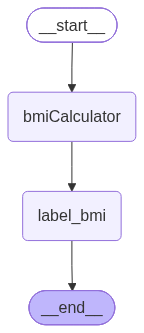

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
